In [1]:
%%html
<style>
    table {
        margin-left: 0 !important;
        margin-right: auto !important;
        text-align: left;
    }
    th, td {
        text-align: left !important;
    }
</style>

# Foundations for Predictive Analytics

[***Algorithm***](https://en.wikipedia.org/wiki/Algorithm) is the term you use when it is not optimal to explain your full solution to a given problem. 

In [2]:
from data.algorithms import *

In all seriousness, this notebook shows how machine learning algorithms can assist with decision making on real problems. Consider the problem of predicting 30-day hospital readmission risk for patients. Knowing patient likelihood to be readmitted allows hospitals to prioritize follow-up care and appropriately allocate space and labor.

## Patient Readmittance Data
This notebook will compare how different algorithms can help you predict readmission using the public, deidentified [UCI Diabetes 130-US Hospitals (1999-2008)](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) dataset for training.

In [3]:
data = ReadmissionDataset().data

Each row is a real inpatient encounter that has been deidentified, not a synthetic patient. The first 5 examples are shown below:

In [4]:
data.dataframe.head(5)

,age,prior_inpatient_visits,number_diagnoses,time_in_hospital,num_medications,number_emergency,number_outpatient,on_diabetes_med,actual_readmit
0,5,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0
1,15,0.0,9.0,3.0,18.0,0.0,0.0,1.0,0
2,25,1.0,6.0,2.0,13.0,0.0,2.0,1.0,0
3,35,0.0,7.0,2.0,16.0,0.0,0.0,1.0,0
4,45,0.0,5.0,1.0,8.0,0.0,0.0,1.0,0


## Problem Setup

Every model is set up to solve the same problem from the data set, which can be represented with the following equation:

<div style="text-align: left; display: inline-block;">
    $$\hat{y} = f(\mathbf{x}) \approx P(\text{y=1} \mid \mathbf{x})$$
</div>

**Where:**

- $\widehat{y}$ = Predicted readmission risk
- $f$ = The learning algorithm
- $\mathbf{x}$ = Patient feature vector (age, prior visits, diagnoses, …)

The output of each model is a prediction that a given discharged patient will be readmitted within 30 days, $P(y=1)$, given their feature vector, $\mathbf{x}$.

In [5]:
X, y = data.X, data.y
feature_names = data.feature_names

| Feature | Meaning |
| --- | --- |
| `age` | Interval for ages of patient e.g. 20-30 years old |
| `prior_inpatient_visits` | Inpatient visits in the prior year |
| `number_diagnoses` | Number of diagnoses on the encounter |
| `time_in_hospital` | Length of stay (days) |
| `num_medications` | Count of medications |
| `number_emergency` | Emergency visits in the prior year |
| `number_outpatient` | Outpatient visits in the prior year |
| `on_diabetes_med` | Whether the patient is on a diabetes medication ($1$ = yes) |

Show the percentage of patients in the dataset that were readmitted within 30 days:

In [6]:
print(f'Readmission prevalence in UCI data: {(y.mean()*100):.2f}%')

Readmission prevalence in UCI data: 11.39%


### Training, Validation, and Test Data

To keep the model blind from certain, the encounters are split into three roles so that models do not peek at the final score:

- **Train** (`X_train` / `y_train`): fit weights, splits, and ensembles. Readmittance is known to the model.
- **Validation** (`X_val` / `y_val`): pick hyperparameters that are not part of `fit` — tree depth and the F1 decision threshold. If we tuned those on the test split, the reported metrics would be optimistically biased.
- **Test** (`X_test` / `y_test`): frozen holdout. Score each model once after train + validation are done. This tells us how the model should behave on new patients.

The default split is stratified **60 / 20 / 20** via `split_train_val_test` in `algorithms.py`.

In [7]:
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y, test_size=0.20, val_size=0.20, random_state=42)

In [8]:
print(
    f'Train size: {X_train.shape[0]} | '
    f'Validation size: {X_val.shape[0]} | '
    f'Test size: {X_test.shape[0]}'
)

Train size: 59605 | Validation size: 19869 | Test size: 19869


Using the split data sets, dataframes are stored for the train, validation, and test encounters.

In [9]:
train_df = pd.DataFrame(X_train, columns=feature_names)
train_df['actual_readmit'] = y_train.astype(int)
val_df = pd.DataFrame(X_val, columns=feature_names)
val_df['actual_readmit'] = y_val.astype(int)

In [10]:
test_df = pd.DataFrame(X_test, columns=feature_names)
test_df['actual_readmit'] = y_test.astype(int)

# Prediction Models

<img
    src='https://substackcdn.com/image/fetch/$s_!g-NR!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F1d6c0a46-7505-491d-a08e-b3d832c3ded3_735x500.jpeg' 
    width='300px' 
/>

This notebook will look at a few different models that can help us make a prediction:
1. Logistic regression
2. Decision trees
3. Random forests
4. Neural networks
5. Recursive reweighting

***Why use multiple algorithms?***

The goal is not to find the fanciest model. Each predictive model has tradeoffs with accuracy, recall, explainability, and operational reliability. Different algorithms fail in different ways, making comparison part of responsible model selection. You will see this more at the end of the notebook.

**Decision consequences**:
- False negatives: truly high-risk patients are not predicted and need to use hospital resources.
- False positives: low-risk patients are tagged for readmission and the hospital overallocates their resources.

Each model will save final predictions to `tuned_outputs` for comparison at the end of the notebook.

In [11]:
tuned_outputs = {}

## 1) Logistic Regression

[Logistic regression](https://en.wikipedia.org/wiki/Logistic_regression) is a standard analytics baseline for binary outcomes. It models the probability of 30-day readmission with the following equation:

<div style="text-align: left; display: inline-block;">
$$
P(y=1 \mid \mathbf{x}) = \sigma(\theta_0 + \theta_1 x_1 + \cdots + \theta_8 x_8)
= \frac{1}{1 + e^{-(\theta_0 + \boldsymbol{\theta}^\top \mathbf{x})}}
$$
</div>
<br>

**Where:**

| Symbol | Meaning |
| --- | --- |
| $\sigma(\cdot)$ | Sigmoid / logistic function, maps any real score into $(0, 1)$ |
| $\theta_j$ | Log-odds coefficient for feature $x_j$ |
| $e^{\theta_j}$ | Odds ratio: multiplicative change in odds per unit increase in $x_j$ |
| $\theta_0$ | Intercept (baseline log-odds) |
| $\widehat{p}$ | Predicted readmission probability; classify if $\widehat{p} \ge$ threshold |

**Strengths:**
- Outputs are easy to interpret with coefficients. 
- Easy to explain to clinical / ops stakeholders, taught in most MBA programs.
- Strong default teaching baseline before implementing trees and ensemble methods.

**Weaknesses:**
- Misses complex (non-linear) relationships unless they are manually engineered.
- Sensitive to outliers in training data, which skew coefficients.
- High vulnerability to multicollinearity... if two or more variables impact an outcome, coefficients become unstable, and difficult to interpret... this is the case for almost all real world problems.
- High risk of mathematical bias and is prone to underfitting - especially when introduced to real-world data.

#### Training

During training, the model estimates $\theta$ from the encounter sample:

- **Input columns:** the eight clinical / utilization features in `feature_names`
- **Output column:** `actual_readmit` ($0$ / $1$)


In [12]:
logit = LogisticRegression(random_state=42)
logit.fit(X_train, y_train)

$\theta_0$ represents the [log odds](https://www.statisticshowto.com/log-odds/) of the target event happening when all features are zero. In this case a negative $\theta_0$ value indicates the patient will not be readmitted within 30 days.

In [13]:
print(f'Intercept (theta_0): {logit.model.intercept_[0]:.4f}')
display(logit.coefficient_table(feature_names))

Intercept (theta_0): -1.4008


,feature,theta,odds_ratio
0,prior_inpatient_visits,0.310475,1.364073
1,on_diabetes_med,0.186625,1.205175
2,number_emergency,0.061509,1.063440
3,number_diagnoses,0.046117,1.047197
4,time_in_hospital,0.034255,1.034849
5,number_outpatient,-0.009313,0.990731
6,age,0.006811,1.006834
7,num_medications,0.001986,1.001988


*In this instance, it looks like prior inpatient visits is the strongest indicator for readmission*

#### Tuning Notes

Coefficients stay fixed after training. `logit.tune(...)` picks the F1 threshold on **validation**, then stores test predictions for the shared comparison at the end.

In [14]:
logit_result, logit_tuned = logit.tune(X_train, y_train, X_val, y_val, X_test, y_test)
tuned_outputs['LogisticRegression'] = logit_tuned

## 2) Decision Trees

A decision tree can be thought of as a flowchart of yes/no questions about patient features. It is usually the easiest model to explain. Each node is some feature threshold, for example age ≤ 65.

<img
    src='./data/gifs/decision_tree_split.gif' 
    width='600px' 
/>

**Strengths:**
- Highly interpretable decision logic.
- Fast to train and easy to explain to non-ML stakeholders.

**Weaknesses:**
- Unstable: small data changes can produce a different tree.
- Deep trees tend to overfit quickly.

We start with the same UCI features used in logistic regression.

In [15]:
print(f'Current decision-tree features: {feature_names}')

Current decision-tree features: ['age', 'prior_inpatient_visits', 'number_diagnoses', 'time_in_hospital', 'num_medications', 'number_emergency', 'number_outpatient', 'on_diabetes_med']


### Training Trees

The trees are trained on the original features only to start. A helper class is created to set benchmarks for every tree based on the feature set. One of the key things this does is help establish the optimal depth for the tree (when to break-off and make the prediction).

In [16]:
benchmarker = TreeBenchmarker(random_state=42)
depth_results = benchmarker.depth_sweep(X_train, y_train, X_val, y_val)

The plot below shows that after a certain amount of decisions, the tree will start to overfit. Meaning the amount of correct decisions in the training set will yield poor results on unknown examples.

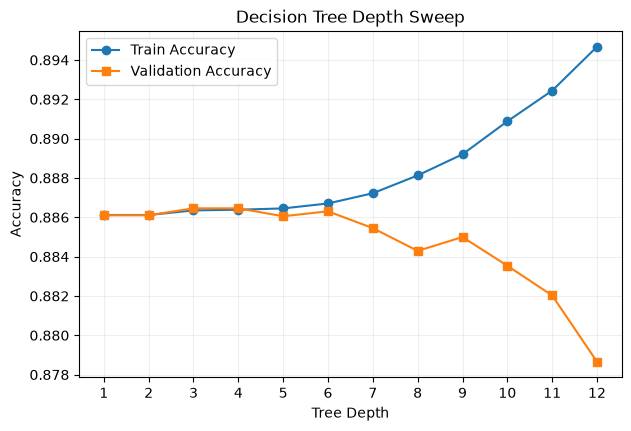

In [17]:
plot_depth_sweep(depth_results)

When trees are too deep they essentially solve for the specific examples in the training set instead of solving for what is true in any example.

In [18]:
best_depth_row = max(depth_results, key=lambda row: row['test_accuracy'])
print(f"Best depth on validation set: {best_depth_row['max_depth']}")

Best depth on validation set: 3


Set up a [decision tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) with the optimal depth.

In [19]:
dt_tuned = DecisionTreeClassifier(
    max_depth=best_depth_row['max_depth'],
    class_weight='balanced',
    random_state=42,
)

The scikit class reads the features passed in and tries splits on all the features that show the most readmit vs not. It then picks the split that most "purifies" the data - the group of patients from the resulting split is almost entirely readmit or entirely not readmit. The splits are repeated on the left and right decision nodes until the max depth is hit (or the node is too small / already pure).

In [20]:
dt_tuned.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

Score the fitted tree on validation (to pick a threshold) and then on test (frozen evaluation).

#### Decision Tree Tuning Notes

`class_weight='balanced'` upweights rare readmits. The F1 cutoff is chosen on validation and applied to test. Stored as `tuned_outputs['DecisionTree']`.


In [21]:
dt_val_scores = dt_tuned.predict_proba(X_val)[:, 1]
dt_test_scores = dt_tuned.predict_proba(X_test)[:, 1]
tuned_outputs['DecisionTree'] = pack_tuned_output(y_val, dt_val_scores, dt_test_scores)

#### Stack logistic $\widehat{p}$ in the tree

Now, decision trees are cool because you can add features to your data set $\therefore$ mathmatical patterns in the dataset can become features for your tree. All that hard work to identify logistic probability might be useful.

Below, the $\widehat{p}$ scores we saved from the logistic regression model are pulled into memory:

In [22]:
phat_train = tuned_outputs['LogisticRegression']['train_scores'].reshape(-1, 1)
phat_val = tuned_outputs['LogisticRegression']['val_scores'].reshape(-1, 1)
phat_test = tuned_outputs['LogisticRegression']['scores'].reshape(-1, 1)

Add $\widehat{p}$ to the set of features and train a new decision tree.

In [23]:
X_train_stacked = np.hstack([X_train, phat_train])
X_val_stacked = np.hstack([X_val, phat_val])
X_test_stacked = np.hstack([X_test, phat_test])
stacked_feature_names = feature_names + ['logit_p_hat']

In [24]:
print(f'Current decision-tree features: {stacked_feature_names}')

Current decision-tree features: ['age', 'prior_inpatient_visits', 'number_diagnoses', 'time_in_hospital', 'num_medications', 'number_emergency', 'number_outpatient', 'on_diabetes_med', 'logit_p_hat']


A new decision tree is created and trained with $\widehat{p}$ added.

In [25]:
dt_stacked = DecisionTreeClassifier(
    max_depth=best_depth_row['max_depth'],
    class_weight='balanced',
    random_state=42,
)

In [26]:
dt_stacked.fit(X_train_stacked, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [27]:
dt_stacked_val_scores = dt_stacked.predict_proba(X_val_stacked)[:, 1]
dt_stacked_scores = dt_stacked.predict_proba(X_test_stacked)[:, 1]

In [28]:
tuned_outputs['DecisionTree+logit_p_hat'] = pack_tuned_output(
    y_val, dt_stacked_val_scores, dt_stacked_scores
)

In [29]:
importance = pd.DataFrame({
    'feature': stacked_feature_names,
    'importance': dt_stacked.feature_importances_,
}).sort_values('importance', ascending=False)

Importance shows the percentage of "useful splits" for a given feature. The more splits on the training data, the more useful the feature is considered for the tree.

In [30]:
display(importance)

,feature,importance
8,logit_p_hat,0.969722
1,prior_inpatient_visits,0.030278
0,age,0.000000
2,number_diagnoses,0.000000
3,time_in_hospital,0.000000
4,num_medications,0.000000
5,number_emergency,0.000000
6,number_outpatient,0.000000
7,on_diabetes_med,0.000000


In this instance $\widehat{p}$ became the most important feature with prior inpatient visits having some small consideration. Both trees are now in `tuned_outputs` for the shared evaluation at the end of the notebook.

## 3) Random Forest

One decision tree can be brittle. A [random forest model](https://developers.google.com/machine-learning/decision-forests/random-forests) trains many trees on slightly different feature subsets then averages their votes. It is a strong default for tabular health data.

<img
    src='./data/gifs/random_forest_vote.gif' 
    width='600px' 
/>

**Strengths:**
- Strong default performance on tabular data.
- More robust than a single tree due to ensembling.

**Weaknesses:**
- Less interpretable than a single tree.
- Heavier model with more compute/storage overhead.

Below implements the [Random Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) class from sci-kit learn.

In [31]:
rf_tuned = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
)

In [32]:
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionch

In [33]:
rf_val_scores = rf_tuned.predict_proba(X_val)[:, 1]
rf_test_scores = rf_tuned.predict_proba(X_test)[:, 1]

### Random Forest Tuning Notes

Class-balanced forest; F1 threshold is chosen on validation, then applied to test.


In [34]:
tuned_outputs['RandomForest'] = pack_tuned_output(y_val, rf_val_scores, rf_test_scores)

## 4) Neural Network

Neural networks are the foundational model behind modern LLMs like ChatGPT. For many structured risk tasks, decision trees and random forests are often better suited because they are easier to explain, validate, and operationalize.

<img
    src='./data/gifs/neural_net_flow.gif' 
    width='600px' 
/>

**Strengths:**
- Captures non-linear interactions among risk factors.
- Can model subtle combinations that linear-style rules miss.

**Weaknesses:**
- Harder to interpret clinically than tree rules.
- Requires tuning and enough data to be stable.

In this notebook, we are using a tiny neural net on a modest sample of public encounters, so this is only a narrow-scope demonstration rather than a production-scale setup.

In [35]:
nn = TinyNeuralNetClassifier(
    input_dim=X_train.shape[1],
    hidden_dim=24,
    learning_rate=0.01,
    epochs=2200,
    random_state=42,
)

In [36]:
nn_result = ModelEvaluator.evaluate(
    nn,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name='TinyNeuralNet',
)

In [37]:
nn_val_scores = nn.predict_proba(X_val)[:, 1]
nn_test_scores = nn.predict_proba(X_test)[:, 1]

### Neural Net Tuning Notes

In the adjacent tuning cell, we keep model training fixed and tune the prediction threshold to improve F1.

In [38]:
tuned_outputs['TinyNeuralNet'] = pack_tuned_output(y_val, nn_val_scores, nn_test_scores)

## 5) Recursive Learning

Now we recursively focus on mistakes using shallow trees that take turns focusing on what the previous tree got wrong. We start with equal weight on every training patient and fit a tree with a depth of 2. Each round increases weight on misclassified patients, forcing the next shallow tree to spend capacity where the previous model failed. We'll start with 18 rounds. Instead of a random forest, where trees are independent and vote equally, these trees are sequential and unequal - later trees chase residuals and strong trees have a more significant vote.

<img
    src='./data/gifs/recursive_reweight.gif' 
    width='600px' 
/>

**Strengths:**
- Often improves performance on hard-to-classify cases.
- Useful when recall/F1 needs improvement.

**Weaknesses:**
- Can over-focus on noisy outliers if not regularized.
- More sensitive to hyperparameters and stopping rules.

In [39]:
recursive_ensemble = RecursiveReweightingEnsemble(
    rounds=18,
    depth=2,
    learning_rate=0.8,
    random_state=42,
)

With the training data, a diagnostic is plotted for each of the 18 rounds. Accuracy on the left is showing how often the round's tree (with current weights) matches the training label in blue and how the ensemble so far (all trees up to the plotted round) scores on the validation set. On the right is the share of sample weight on patients the round's tree got incorrect. This is the error used to determine each tree's vote strength.

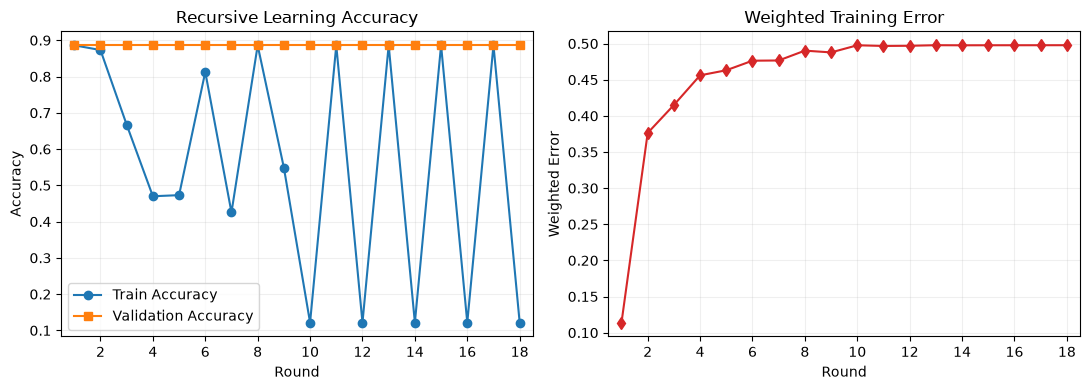

In [40]:
recursive_ensemble.fit(X_train, y_train, X_val, y_val)
plot_recursive_history(recursive_ensemble.history_)

On the left, the orange line is the ensemble so far, since readmission in the dataset is ~11%, which means predicting always a non readmit is ~89% accurate. The combined model is always sitting on that majority call, so validation barely moves. The blue line is plotting each round on the training rows, unweighted. After a round, mistakes get a large weight (likely the rare readmits), so the next round chases those points and calls readmit more often than it should. This then causes the next tree to flip back because the opposite errors get the weight.

On the right, you'll see a low error because with equal weight the shallow tree hardly ever calls readmit and will miss the ~11% in the dataset. After each round, the weight piles on the examples that were incorrect. The error spikes up because each new tree faces a tougher weighted problem. It eventually flatlines around round 10, indicating it stops helping.

In [41]:
recursive_result = recursive_ensemble.evaluate(X_test, y_test)
recursive_result['model'] = 'RecursiveReweightingEnsemble'

In [42]:
recursive_val_scores = recursive_ensemble._decision_score(X_val)
recursive_test_scores = recursive_ensemble._decision_score(X_test)

Score range is model-specific, so tune within observed bounds.

In [43]:
rec_thresholds = np.linspace(
    min(recursive_val_scores.min(), recursive_test_scores.min()),
    max(recursive_val_scores.max(), recursive_test_scores.max()),
    41,
)

### Recursive Tuning Notes

In the adjacent tuning cell, we tune the final cutoff over recursive ensemble scores to improve F1 and positive capture.

In [44]:
tuned_outputs['RecursiveReweighting'] = pack_tuned_output(
    y_val,
    recursive_val_scores,
    recursive_test_scores,
    thresholds=rec_thresholds,
)

# Evaluate Model Performance

This section scores every model in `tuned_outputs` on the same held-out test labels.

## Performance Metrics

| Metric | Description | Indicator |
| --- | --- | --- |
| Accuracy | Share of patients classified correctly. | Higher is better, but can look strong if most patients are not readmitted. |
| Precision | Of predicted readmits, how many truly were. | Higher ⇒ fewer false alarms. |
| Recall | Of true readmits, how many were found. | Higher ⇒ fewer missed high-risk patients. |
| F1 | Balance of precision and recall. | Useful when both misses and false alarms matter. |

Models are sorted by **accuracy** in the chart so the strongest overall classifiers are easiest to spot. For readmission ops, also check recall/F1 — accuracy alone can hide missed positives.


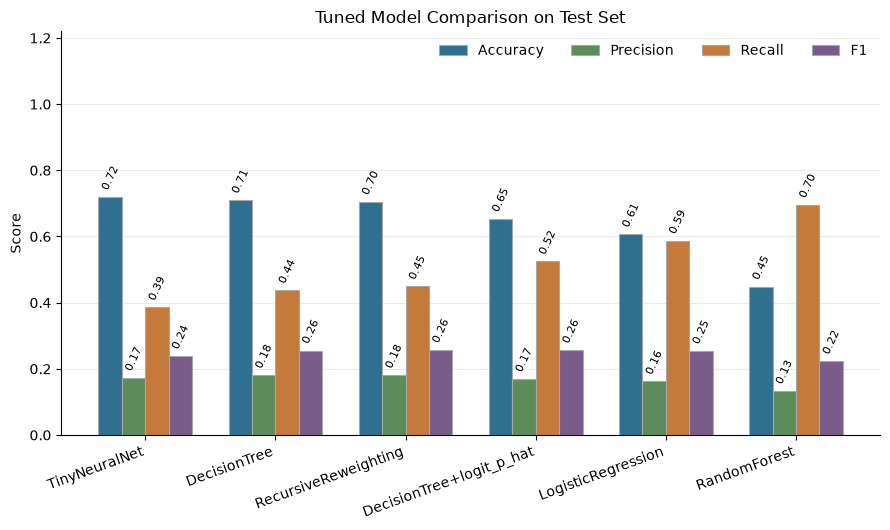

In [45]:
plot_model_comparison(tuned_outputs, y_test)

In [46]:
display(model_metrics_table(tuned_outputs, y_test))

,model,accuracy,precision,recall,f1
0,TinyNeuralNet,0.719412,0.172598,0.385771,0.238492
1,DecisionTree,0.709346,0.180146,0.437030,0.255127
2,RecursiveReweighting,0.704817,0.180334,0.448962,0.257313
3,DecisionTree+logit_p_hat,0.653128,0.169499,0.524525,0.256205
4,LogisticRegression,0.606724,0.161813,0.586832,0.253677
5,RandomForest,0.448437,0.132894,0.695537,0.223152


# Feature Selection and Retraining

These results indicate that our models are not exactly reliable to base a real decisions on yet. Consider what we might do to improve this in a real hospital setting so that they are. We would still have the same general idea: tabular classifier → risk score → cutoff; but we would have access to more useful features. 

A few to consider if we were using a full EHR platform as our source system:
- Deaths/hospice were already dropped in this model, but we could also have timestamps on when features are known with status fields.
- We would split training data using the timestamps, e.g.train on cases from beginning of time until 2024. Validate/Test on 2025 and 2026 cases.
- Procedures, labs, vitals, medications, and additional features would be included ~ likely hundreds of candidates would be considered, not just 8.
- Metrics like [AUC, PR-AUC](https://leonidasgorgo.medium.com/understanding-roc-auc-and-pr-auc-c488faf45a16), [calibration](https://medium.com/@sahilbansal480/understanding-model-calibration-in-machine-learning-6701814dbb3a), and [decision curves](https://en.wikipedia.org/wiki/Decision_curve_analysis) would be evaluated.
- Slices would be made and evaluated on age, race, site, and diagnosis groups.
- Cutoff would not be "max F1 on a grid", it would consider the hospital's actual capacity or flag a top % of risky patients. The threshold follows capacity and cost of misses/false alarms.
- [Gradient boosting](https://www.ibm.com/think/topics/gradient-boosting) or [regularized logistic/scorecards](https://www.sciencedirect.com/science/article/pii/S2352711026003225) are the usual defaults. Tiny neural nets and homemade boosting are really just teaching tools.
- Far greater validation and deployment logging would be implemented, including a human review.
- Retraining would be scheduled on data is updated live, not a one-and-done extract.